# Handwritten Character Recognition using CNN

This notebook demonstrates building a Convolutional Neural Network (CNN) to recognize handwritten digits using the MNIST dataset.

## 1. Import Libraries
Importing required libraries for deep learning, data manipulation, and visualization.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# Ensure directories exist
os.makedirs('charts', exist_ok=True)
os.makedirs('outputs', exist_ok=True)


## 2. Load and Preprocess Dataset
Loading the MNIST dataset, normalizing pixel values to the range [0, 1], and reshaping the data to include a channel dimension (28, 28, 1).

In [2]:
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f"Original X_train shape: {X_train.shape}")
print(f"Original X_test shape: {X_test.shape}")

# Normalize pixel values
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Reshape to include channel dimension (1 for grayscale)
X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print(f"Preprocessed X_train shape: {X_train.shape}")
print(f"Preprocessed X_test shape: {X_test.shape}")


       0/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

   16384/11490434 ━━━━━━━━━━━━━━━━━━━━ 1:49 10us/step

   40960/11490434 ━━━━━━━━━━━━━━━━━━━━ 1:03 6us/step 

   49152/11490434 ━━━━━━━━━━━━━━━━━━━━ 1:42 9us/step

   81920/11490434 ━━━━━━━━━━━━━━━━━━━━ 1:28 8us/step

...

10764288/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

11165696/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Original X_train shape: (60000, 28, 28)
Original X_test shape: (10000, 28, 28)


Preprocessed X_train shape: (60000, 28, 28, 1)
Preprocessed X_test shape: (10000, 28, 28, 1)


## 3. Visualize Sample Images
Let's view some examples from the training dataset.

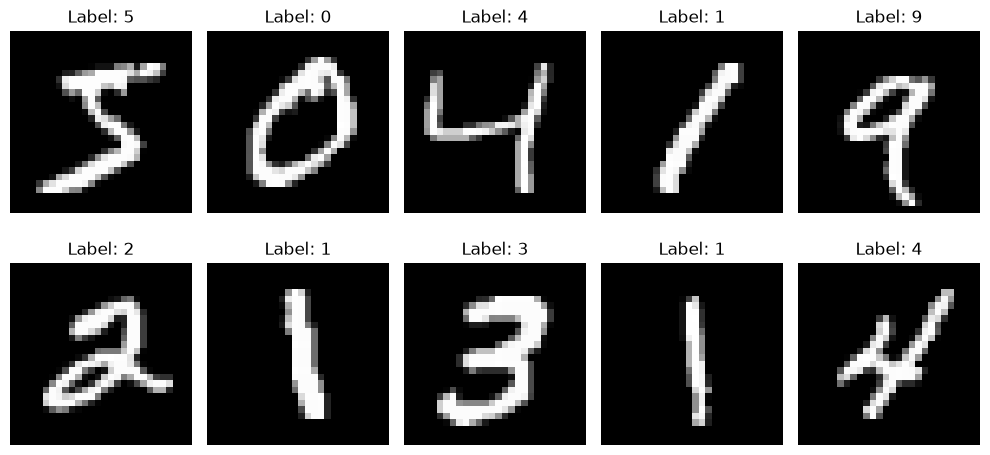

In [3]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i].squeeze(), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.savefig('charts/sample_images.png', bbox_inches='tight')
plt.show()


## 4. CNN Architecture
Building the Convolutional Neural Network. We use Conv2D layers for feature extraction, MaxPooling2D for downsampling, Batch Normalization for training stability, and Dropout to prevent overfitting.

In [4]:
model = Sequential([
    # First Convolutional Block
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    
    # Second Convolutional Block
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    
    # Fully Connected Layers
    Flatten(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,930 (882.54 KB)

 Trainable params: 225,482 (880.79 KB)

 Non-trainable params: 448 (1.75 KB)

## 5. Model Training
Training the model for up to 20 epochs, using EarlyStopping to halt training if the validation loss does not improve for 3 consecutive epochs.

In [5]:
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

history = model.fit(
    X_train, y_train_cat,
    validation_split=0.1,
    epochs=20,
    batch_size=128,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/20


  1/422 ━━━━━━━━━━━━━━━━━━━━ 32:20 5s/step - accuracy: 0.0938 - loss: 3.8151

  2/422 ━━━━━━━━━━━━━━━━━━━━ 29s 70ms/step - accuracy: 0.1289 - loss: 3.4335

  4/422 ━━━━━━━━━━━━━━━━━━━━ 23s 56ms/step - accuracy: 0.2266 - loss: 2.8762

  6/422 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.2930 - loss: 2.5245

...

421/422 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9900 - loss: 0.0307

422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9900 - loss: 0.0307

422/422 ━━━━━━━━━━━━━━━━━━━━ 31s 74ms/step - accuracy: 0.9900 - loss: 0.0307 - val_accuracy: 0.9922 - val_loss: 0.0289


Epoch 14: early stopping


Restoring model weights from the end of the best epoch: 11.


## 6. Plot Learning Curves
Visualizing the training and validation accuracy/loss to check for overfitting.

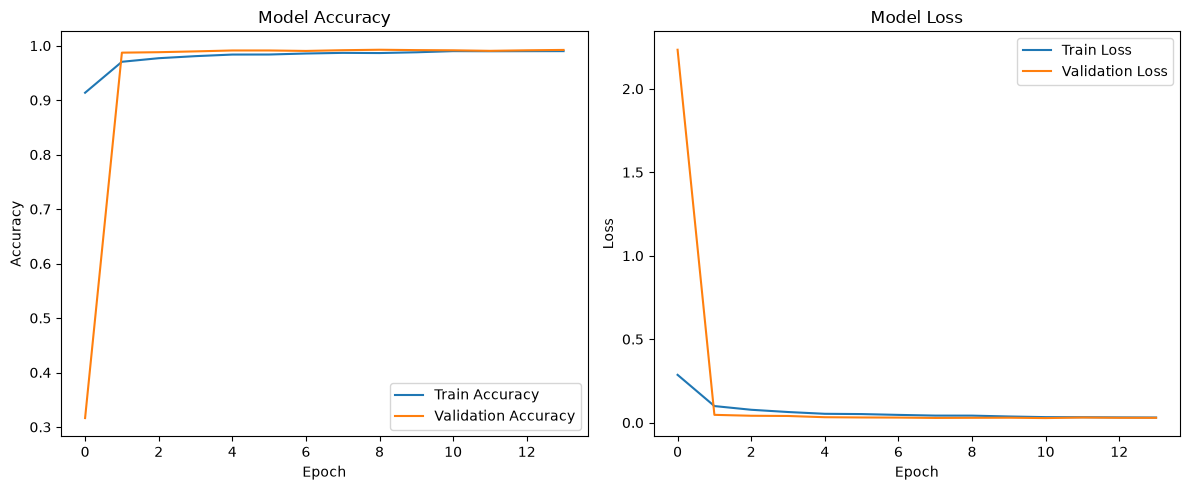

In [6]:
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('charts/learning_curves.png', bbox_inches='tight')
plt.show()


## 7. Model Evaluation
Evaluating the model on the unseen test set and generating comprehensive metrics.

  1/313 ━━━━━━━━━━━━━━━━━━━━ 1:53 364ms/step

  6/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step   

 12/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step

 18/313 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step

 24/313 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step

...

305/313 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step


Test Accuracy:  0.9914
Test Precision: 0.9914
Test Recall:    0.9914
Test F1-Score:  0.9914


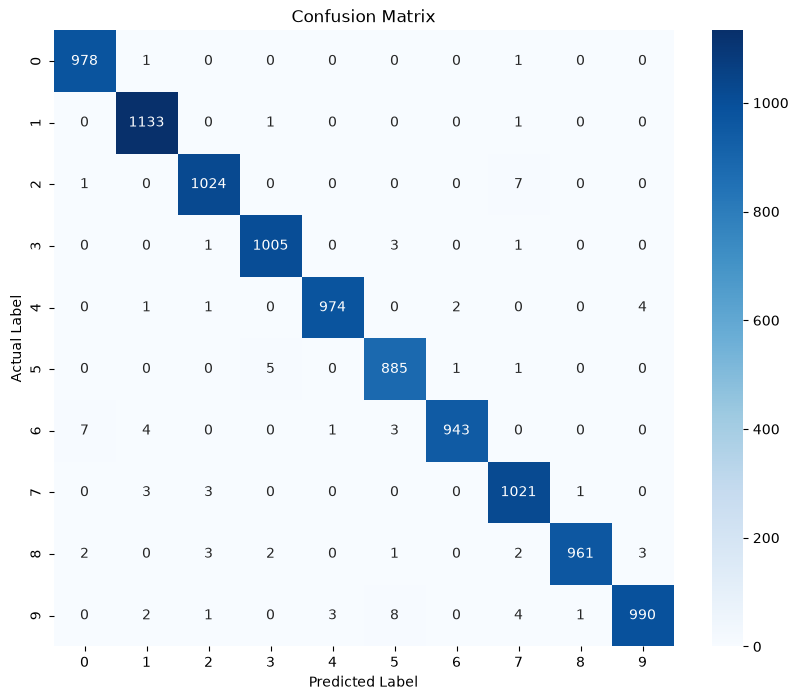

Predictions saved to outputs/predictions.csv


In [7]:
# Get Predictions
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Test Accuracy:  {acc:.4f}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall:    {rec:.4f}")
print(f"Test F1-Score:  {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.savefig('charts/confusion_matrix.png', bbox_inches='tight')
plt.show()

# Export Predictions
predictions_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
predictions_df.to_csv('outputs/predictions.csv', index=False)
print("Predictions saved to outputs/predictions.csv")


## 8. Sample Predictions
Displaying a few sample predictions with their actual vs predicted labels.

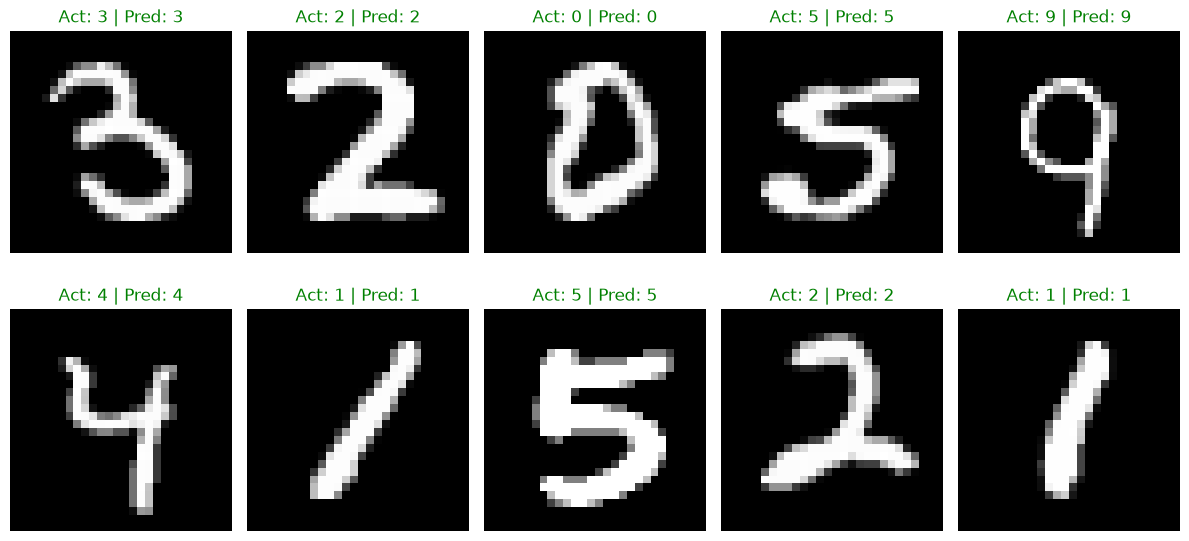

In [8]:
plt.figure(figsize=(12, 6))
# Select 10 random indices from test set
indices = np.random.choice(len(X_test), 10, replace=False)

for i, idx in enumerate(indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx].squeeze(), cmap='gray')
    color = 'green' if y_test[idx] == y_pred[idx] else 'red'
    plt.title(f"Act: {y_test[idx]} | Pred: {y_pred[idx]}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.savefig('charts/sample_predictions.png', bbox_inches='tight')
plt.show()


## 9. Save Trained Model
Saving the trained CNN model weights and architecture.

In [9]:
model.save('trained_model.keras')
print("Model successfully saved as trained_model.keras")


Model successfully saved as trained_model.keras


## 10. Future Improvements
- **Data Augmentation:** Apply random rotations, zooming, and shifting during training to make the model more robust to varied handwriting styles.
- **Dataset Expansion:** Swap MNIST with EMNIST to build an alphanumeric character recognition system.
- **Hyperparameter Tuning:** Experiment with learning rates, kernel sizes, and number of filters to optimize accuracy further.